# LiDAR de US$100 ve detrás de las paredes

Un sensor más pequeño que una moneda, conectado a un computador común, reconstruyó la posición de un objeto **oculto fuera de su campo de visión** con un error promedio de **3,8 cm**. Hasta este paper, hacer eso requería equipos de laboratorio que cuestan cien veces más.

📄 **Paper**: [Somasundaram et al., Nature 2026](https://doi.org/10.1038/s41586-026-10502-x)  
💻 [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-21-lidar-objetos-ocultos-celular/notebook.ipynb)  
🎬 **Video**: [Ver en YouTube](https://youtube.com/shorts/MXdpzH2G5Yw)


## ¿Qué hicieron?

**NLOS** (*non-line-of-sight imaging*) es la idea de ver objetos que están fuera del campo visual de la cámara — escondidos detrás de una esquina, debajo de un mueble, dentro de un cuarto cerrado. La luz rebota varias veces antes de volver al sensor, y si mides los tiempos con suficiente precisión, puedes reconstruir la escena oculta.

Hasta ahora, esto se hacía con LiDARs científicos de muchos miles de dólares. Los autores lo hicieron con un sensor de **menos de US$100** (el ST VL53L8CX, una pieza que cualquiera puede comprar). El truco: aprovechar que la cámara y el objeto se mueven, y combinar muchos cuadros para sacar la señal del ruido.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ERROR_HEADLINE_CM = 3.8        # error promedio del método propuesto
BASELINE_BACKPROJ_CM = 6.4     # baseline antiguo #1
BASELINE_PHASOR_CM = 15.7      # baseline antiguo #2
FUENTE = 'Fuente: Somasundaram et al. (2026), Nature | Datos: github.com/sidsoma/consumer-nlos + SI'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Estilo CaM (local → fallback raw GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar los 4 CSVs verificados
errores_baselines = pd.read_csv('datos/errores_baselines.csv')
errores_dim = pd.read_csv('datos/errores_por_dimension.csv')
histograma = pd.read_csv('datos/histograma_spad_frame0.csv')
trayectoria = pd.read_csv('datos/trayectoria_tracking.csv')

print(f'Métodos comparados: {len(errores_baselines)} (mejor: {errores_baselines.iloc[0,0]} → {errores_baselines.iloc[0,1]} cm)')
print(f'Configuraciones por dimensión: {len(errores_dim)} (2 objetos × 2 condiciones)')
print(f'Histograma SPAD: {len(histograma)} bins × 16 píxeles (datos disponibles del 4×4)')
print(f'Trayectoria de seguimiento: {len(trayectoria)} cuadros ≈ {len(trayectoria)/5:.0f} s a 5 fps')


Métodos comparados: 3 (mejor: Particle filter (este trabajo) → 3.8 cm)
Configuraciones por dimensión: 4 (2 objetos × 2 condiciones)
Histograma SPAD: 128 bins × 16 píxeles (datos disponibles del 4×4)
Trayectoria de seguimiento: 475 cuadros ≈ 95 s a 5 fps


## El golpe inicial

Tres métodos, el mismo problema. Aquí está.


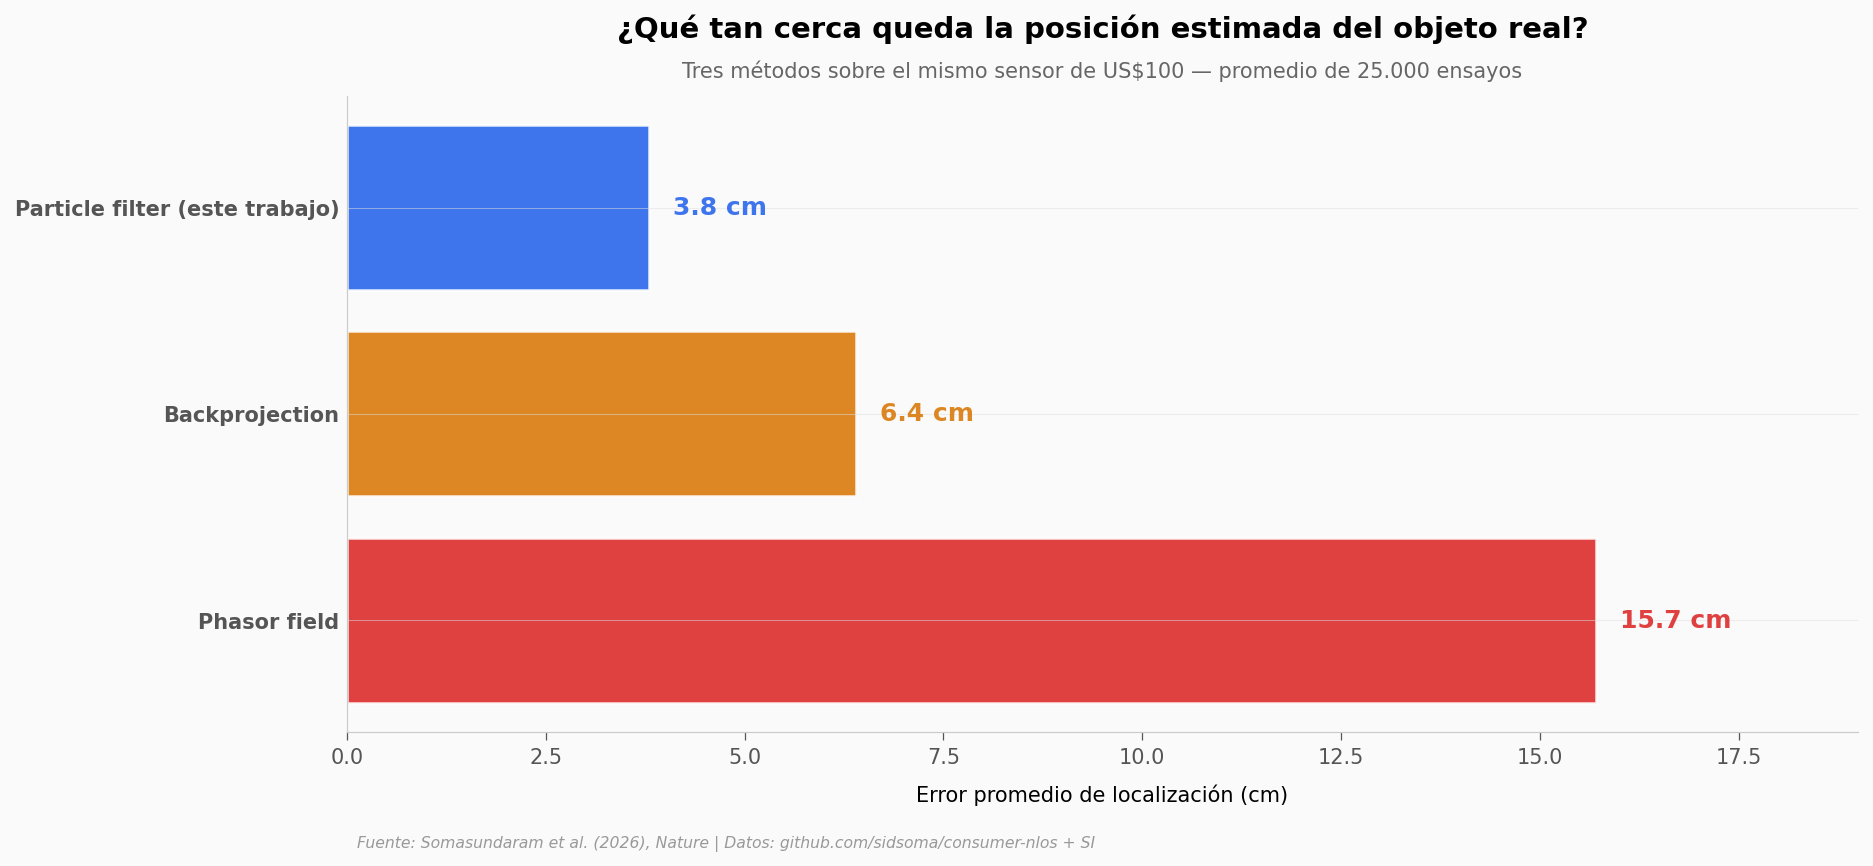

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

metodos = errores_baselines['metodo'].tolist()
errores = errores_baselines['error_promedio_cm'].tolist()
colores = [COLOR_DATOS, COLOR_REFERENCIA, COLOR_ALERTA]

bars = ax.barh(metodos[::-1], errores[::-1], color=colores[::-1], alpha=0.88,
               edgecolor='white', linewidth=1.2)

# Etiquetas de valor al final de cada barra
for bar, val in zip(bars, errores[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val} cm',
            va='center', fontsize=12, fontweight='bold', color=bar.get_facecolor())

ax.set_xlim(0, 19)
ax.set_xlabel('Error promedio de localización (cm)', fontsize=10)
ax.set_title('¿Qué tan cerca queda la posición estimada del objeto real?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Tres métodos sobre el mismo sensor de US$100 — promedio de 25.000 ensayos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_yticks(range(len(metodos)))
ax.set_yticklabels(metodos[::-1], fontsize=10, fontweight='bold')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comparacion_metodos.png', dpi=200, bbox_inches='tight')
plt.show()


El método propuesto (un *particle filter* que combina muchos cuadros del sensor) se queda en **3,8 cm** de error promedio. Los dos baselines clásicos del campo —diseñados originalmente para LiDARs científicos con mucha más señal— quedan en **6,4 cm** y **15,7 cm**. Frente al backprojection, la mejora es **1,7×**; frente al phasor field, **4,1×**.

Importante: este 3,8 cm es el **promedio** sobre 25.000 ensayos. La incertidumbre en cada cuadro individual es mucho mayor — volvemos a eso al final.


## ¿Y si no sabes qué estás buscando?

El sistema no es magia: necesita pistas. La más importante es **la forma del objeto**. Si le dices al algoritmo "estoy buscando un cuadrado de 25×25 cm", se vuelve mucho más preciso. Si no, tiene que adivinar la forma además de la posición — y ahí empieza a sufrir.

Los autores probaron dos objetos: un parche cuadrado de 25×25 cm y una "U" de 40×45 cm. Veamos qué pasa con cada uno.


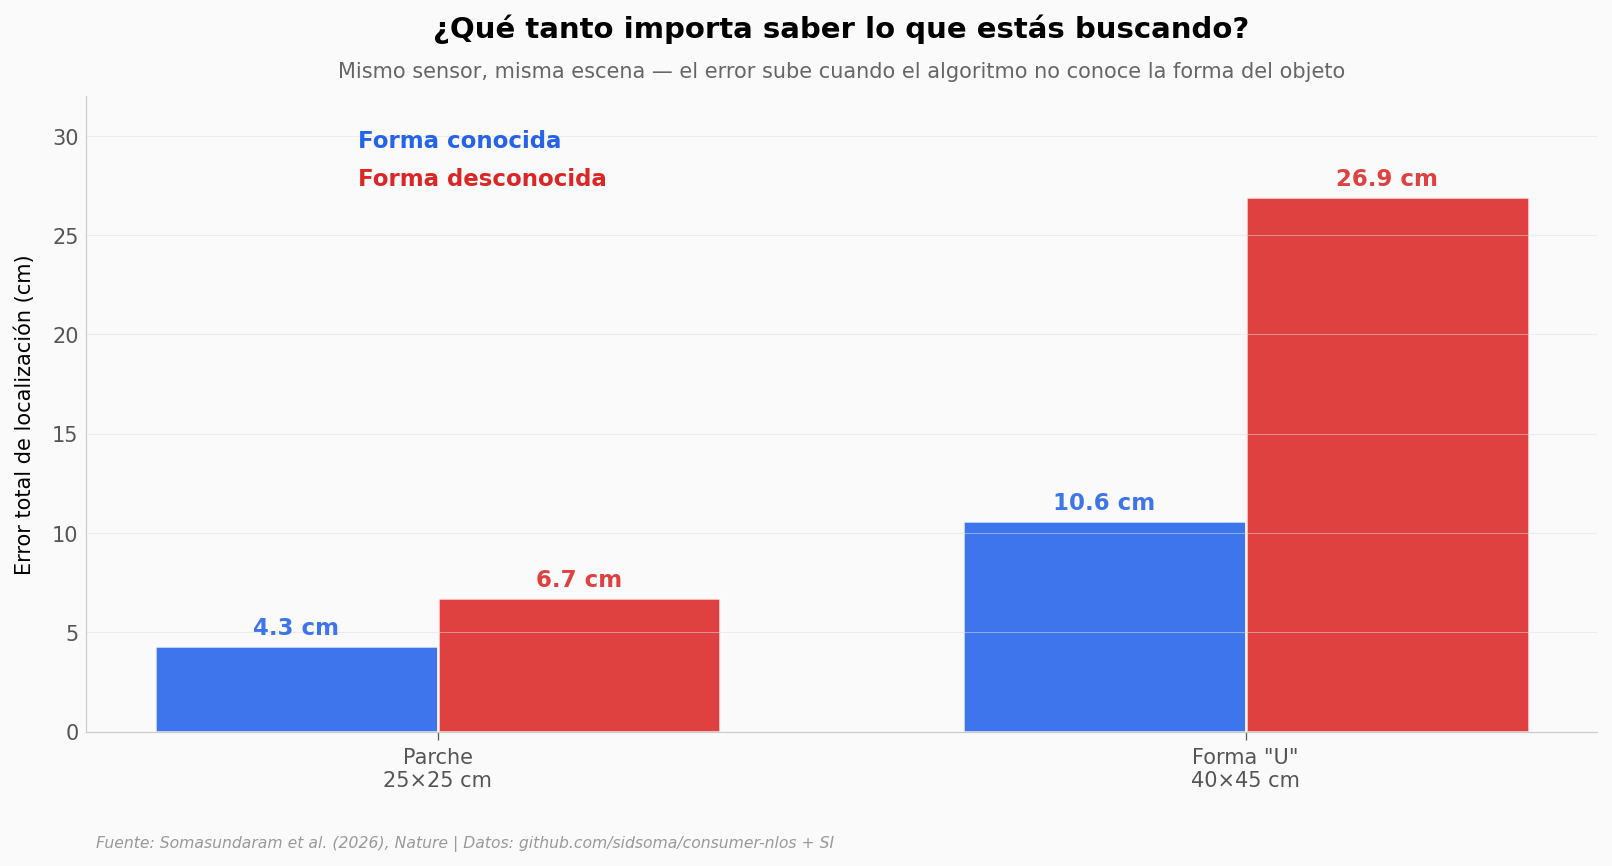

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Reorganizar: 2 objetos × 2 condiciones (con/sin forma conocida)
patch_k = errores_dim[(errores_dim['objeto']=='Patch 25x25 cm') & (errores_dim['forma_conocida'])].iloc[0]
patch_u = errores_dim[(errores_dim['objeto']=='Patch 25x25 cm') & (~errores_dim['forma_conocida'])].iloc[0]
u_k = errores_dim[(errores_dim['objeto']=='U 40x45 cm') & (errores_dim['forma_conocida'])].iloc[0]
u_u = errores_dim[(errores_dim['objeto']=='U 40x45 cm') & (~errores_dim['forma_conocida'])].iloc[0]

labels = ['Parche\n25×25 cm', 'Forma "U"\n40×45 cm']
vals_known = [patch_k['error_total_cm'], u_k['error_total_cm']]
vals_unknown = [patch_u['error_total_cm'], u_u['error_total_cm']]

x = np.arange(len(labels))
w = 0.35
b1 = ax.bar(x - w/2, vals_known, w, color=COLOR_DATOS, alpha=0.88,
            edgecolor='white', linewidth=1.2)
b2 = ax.bar(x + w/2, vals_unknown, w, color=COLOR_ALERTA, alpha=0.88,
            edgecolor='white', linewidth=1.2)

for bar, val in list(zip(b1, vals_known)) + list(zip(b2, vals_unknown)):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.6, f'{val} cm',
            ha='center', fontsize=11, fontweight='bold', color=bar.get_facecolor())

# Inline labels (en lugar de legend box)
ax.text(0.18, 0.92, 'Forma conocida', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color=COLOR_DATOS)
ax.text(0.18, 0.86, 'Forma desconocida', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color=COLOR_ALERTA)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Error total de localización (cm)', fontsize=10)
ax.set_ylim(0, 32)
ax.set_title('¿Qué tanto importa saber lo que estás buscando?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Mismo sensor, misma escena — el error sube cuando el algoritmo no conoce la forma del objeto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/forma_conocida_vs_no.png', dpi=200, bbox_inches='tight')
plt.show()


## El sistema en acción

Hasta aquí los errores son promedios sobre miles de pruebas. Pero el experimento más visual del paper es **seguir a una persona caminando** detrás de la pared. Los autores grabaron 95 segundos (475 cuadros a 5 cuadros por segundo) y dejaron al sistema estimar la trayectoria cuadro a cuadro.

Cada punto azul es la creencia del sistema en un instante. La banda gris alrededor es la incertidumbre — qué tan seguro está el algoritmo de esa posición.


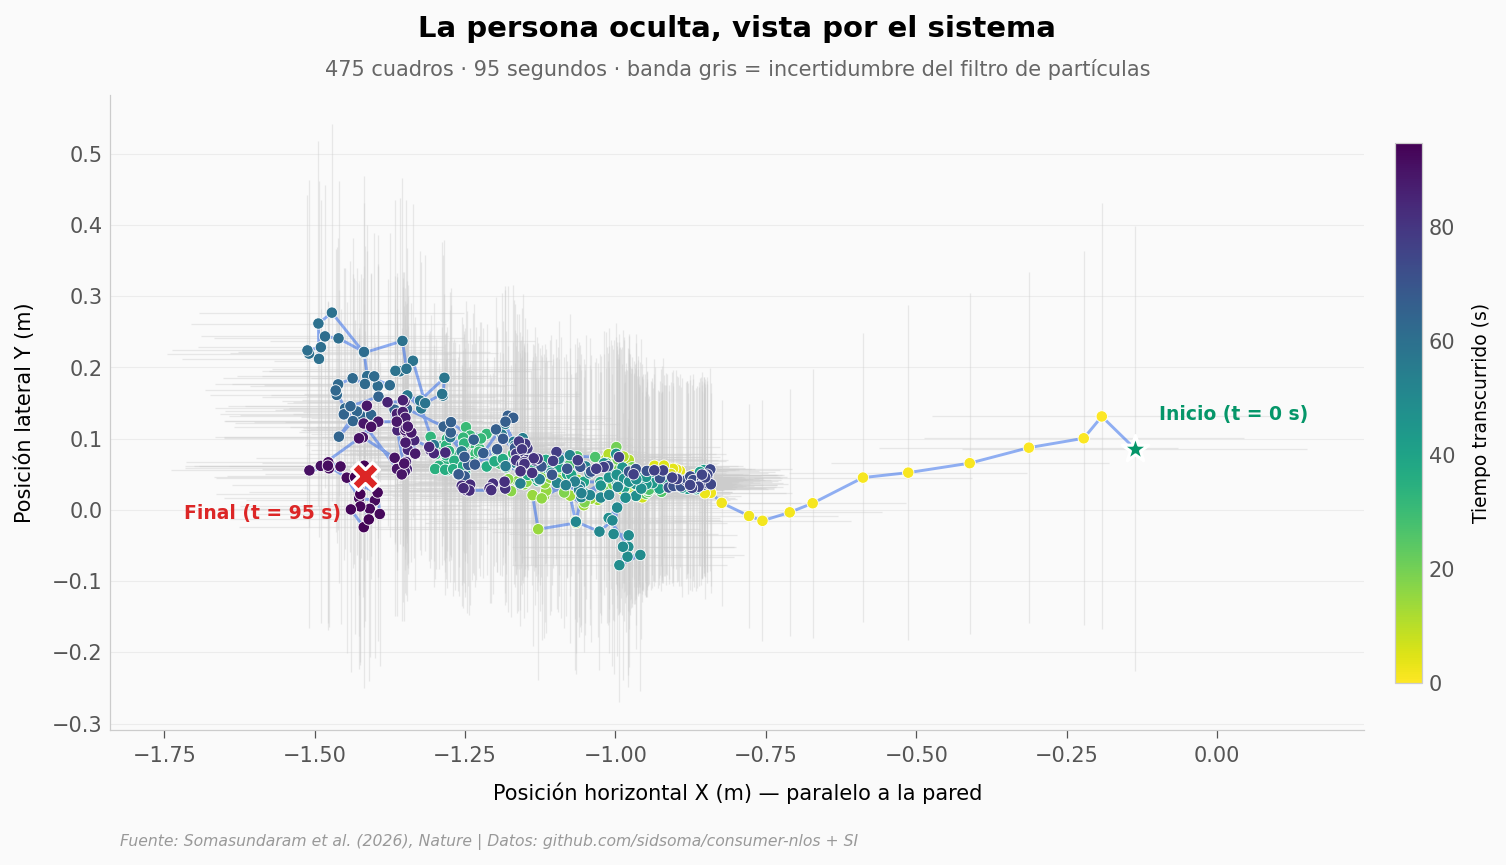

Recorrido en X: 1.38 m
Recorrido en Y: 0.35 m
Incertidumbre promedio en X: 17.0 cm
Incertidumbre promedio en Y: 17.4 cm


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Banda de incertidumbre (1 sigma en X-Y) — fill_between requiere 1D, usamos errorbar lineal
x = trayectoria['x_media_m'].values
y = trayectoria['y_media_m'].values
sx = trayectoria['x_std_m'].values
sy = trayectoria['y_std_m'].values

# Banda fina vertical en cada punto (incertidumbre en Y)
ax.errorbar(x, y, yerr=sy, fmt='none', ecolor='#CCCCCC', alpha=0.4,
            elinewidth=0.6, zorder=2)
# Banda fina horizontal (incertidumbre en X)
ax.errorbar(x, y, xerr=sx, fmt='none', ecolor='#CCCCCC', alpha=0.4,
            elinewidth=0.6, zorder=2)

# Línea de trayectoria estimada
ax.plot(x, y, '-', color=COLOR_DATOS, linewidth=1.4, alpha=0.5, zorder=3)

# Scatter coloreado por tiempo
tiempos = np.arange(len(x)) / 5.0  # segundos
sc = ax.scatter(x, y, c=tiempos, cmap='viridis_r', s=30,
                edgecolors='white', linewidths=0.4, zorder=5)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Tiempo transcurrido (s)', fontsize=9)

# Marcadores inicio / fin
ax.scatter(x[0], y[0], s=180, marker='*', color=COLOR_SECUNDARIO,
           edgecolors='white', linewidths=1.5, zorder=10, label='Inicio')
ax.scatter(x[-1], y[-1], s=180, marker='X', color=COLOR_ALERTA,
           edgecolors='white', linewidths=1.5, zorder=10, label='Final')
ax.text(x[0] + 0.04, y[0] + 0.04, 'Inicio (t = 0 s)', fontsize=9,
        fontweight='bold', color=COLOR_SECUNDARIO)
ax.text(x[-1] - 0.04, y[-1] - 0.06, f'Final (t = {tiempos[-1]:.0f} s)',
        fontsize=9, fontweight='bold', color=COLOR_ALERTA, ha='right')

ax.set_xlabel('Posición horizontal X (m) — paralelo a la pared', fontsize=10)
ax.set_ylabel('Posición lateral Y (m)', fontsize=10)
ax.set_title('La persona oculta, vista por el sistema',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '475 cuadros · 95 segundos · banda gris = incertidumbre del filtro de partículas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/trayectoria.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats útiles para la narrativa
print(f'Recorrido en X: {x.max() - x.min():.2f} m')
print(f'Recorrido en Y: {y.max() - y.min():.2f} m')
print(f'Incertidumbre promedio en X: {sx.mean()*100:.1f} cm')
print(f'Incertidumbre promedio en Y: {sy.mean()*100:.1f} cm')


## El número que el titular esconde

El paper publica **3,8 cm** como el error principal. Es el promedio sobre 25.000 ensayos. Pero veamos qué tan ancho es el rango de incertidumbre cuando miras **cada cuadro individual** del seguimiento.


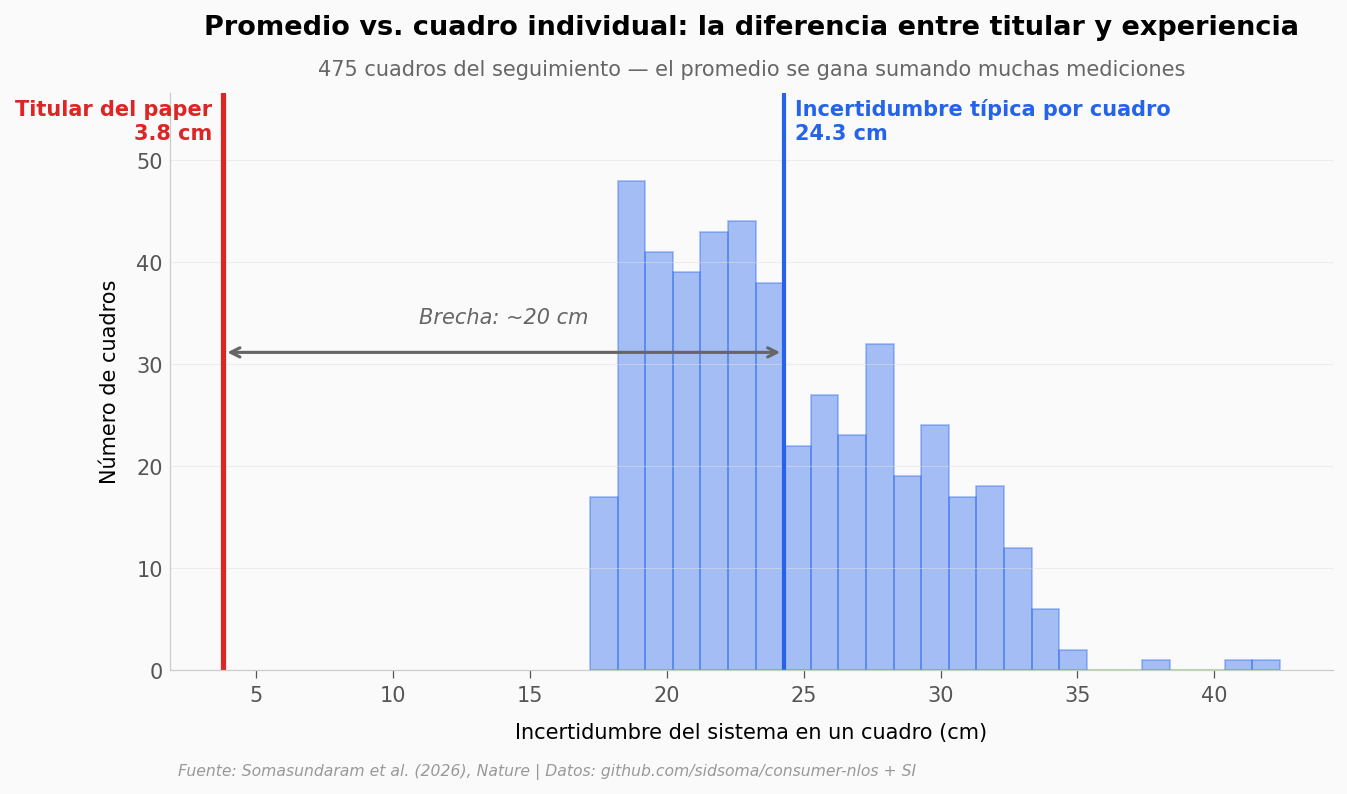

Incertidumbre por cuadro: mediana 23.3 cm, máx 42.4 cm


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Magnitud de incertidumbre por cuadro (longitud del vector std en XY)
incertidumbre_cuadro_cm = np.sqrt(sx**2 + sy**2) * 100

n, bins, patches = ax.hist(incertidumbre_cuadro_cm, bins=25, color=COLOR_DATOS,
                           alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

media_inc = incertidumbre_cuadro_cm.mean()

# Línea: incertidumbre típica por cuadro (azul = sistema)
ax.axvline(x=media_inc, color=COLOR_DATOS, linewidth=2.0)
ax.text(media_inc + 0.4, y_max*0.92,
        f'Incertidumbre típica por cuadro\n{media_inc:.1f} cm',
        fontsize=10, fontweight='bold', color=COLOR_DATOS)

# Línea: el headline 3.8 cm (rojo = lo que se reporta)
ax.axvline(x=ERROR_HEADLINE_CM, color=COLOR_ALERTA, linewidth=2.5)
ax.text(ERROR_HEADLINE_CM - 0.4, y_max*0.92,
        f'Titular del paper\n{ERROR_HEADLINE_CM} cm',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA, ha='right')

# Flecha bidireccional mostrando la brecha
ax.annotate('', xy=(ERROR_HEADLINE_CM, y_max*0.55),
            xytext=(media_inc, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((ERROR_HEADLINE_CM + media_inc)/2, y_max*0.6,
        f'Brecha: ~{media_inc - ERROR_HEADLINE_CM:.0f} cm',
        fontsize=10, color='#666666', ha='center', style='italic')

ax.set_xlabel('Incertidumbre del sistema en un cuadro (cm)', fontsize=10)
ax.set_ylabel('Número de cuadros', fontsize=10)
ax.set_title('Promedio vs. cuadro individual: la diferencia entre titular y experiencia',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '475 cuadros del seguimiento — el promedio se gana sumando muchas mediciones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_incertidumbre.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Incertidumbre por cuadro: mediana {np.median(incertidumbre_cuadro_cm):.1f} cm, '
      f'máx {incertidumbre_cuadro_cm.max():.1f} cm')


La incertidumbre típica en un cuadro individual ronda los **24 cm** — casi 6× el titular de 3,8 cm. La razón es estadística pura: la métrica del paper es el error promedio sobre 25.000 estimaciones, y promediar tiende a esconder la variabilidad instantánea. Si miras **un solo cuadro**, el sistema no sabe dónde está la persona con precisión de centímetros — sabe que está dentro de una región de varios decímetros. Solo cuando agregas muchos cuadros, el ruido se cancela y el promedio cae a la zona del centímetro.

No es trampa: es el régimen estadístico en el que opera el método. Pero merece mención cuando uno lee el titular.


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Error promedio del método propuesto es 3,8 cm | ✅ | Valor literal del SI (Section 5.1), reportado como promedio sobre 25.000 ensayos |
| El método mejora 1,7× sobre backprojection y 4,1× sobre phasor field | ✅ | Aritmética directa sobre los valores del SI (6,4/3,8 ≈ 1,68; 15,7/3,8 ≈ 4,13) |
| Conocer la forma del objeto reduce el error | ✅ | Patch: 4,3 → 6,7 cm (1,56×). "U": 10,6 → 26,9 cm (2,54×) — el efecto es más fuerte en objetos no convexos |
| El sensor cuesta menos de US$100 | ✅ | El ST VL53L8CX/L8CH está en mercado abierto a ese precio |
| La incertidumbre por cuadro es ~24 cm | ✅ | Calculado en el notebook desde la std de las 1.000 partículas, sobre 475 cuadros |
| El sistema funciona en "el LiDAR de tu celular" | ⚠️ | El paper usa el ST VL53L8CX (sensor multizone industrial), NO el LiDAR del iPhone/iPad. La técnica es generalizable, pero los autores no la probaron sobre LiDAR de smartphone reales |

> **Limitaciones (del paper y del notebook):**
> - **Solo 2 baselines comparados** — "mejor método de NLOS" sobreestima: hay otros enfoques (e.g. *learned NLOS*) no incluidos.
> - **Objetos planos, escenas controladas** — no hay validación en habitaciones reales con muebles, cortinas u objetos no convexos arbitrarios.
> - **Algunos datos del *proprietary device* no se liberaron** — lo que sí está abierto es el sensor ST y los scripts del particle filter.
> - **Compromiso temporal** — 5 cuadros por segundo, y mejor desempeño requiere acumular muchos cuadros. No es "video en vivo".


## Ahora tú

1. **¿Cuánto pesa cada cuadro?** Si la incertidumbre por cuadro es ~24 cm y el promedio es 3,8 cm, ¿cuántos cuadros independientes necesitarías promediar para llegar de uno a otro? (Pista: el error del promedio escala con √N.)

2. **El SPAD raw.** El archivo `histograma_spad_frame0.csv` tiene los conteos de fotones de los 16 píxeles activos, cada uno con 128 bins de tiempo (50 ps). ¿En qué bin llega el pico de fotones del píxel central? ¿A cuánta distancia corresponde eso?

3. **¿Y si la forma fuera otra?** Patch (cuadrado) sufre 1,56× sin forma conocida; "U" sufre 2,54×. ¿Qué tipo de objeto crees que sufriría más — uno convexo o uno con concavidades? La celda de abajo te deja explorar.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿en qué bin llega el pico de cada píxel?

VELOCIDAD_LUZ_M_S = 3e8
BIN_WIDTH_PS = 50  # 50 picosegundos por bin

# Buscar el bin con más fotones para cada uno de los 16 píxeles
pixel_cols = [c for c in histograma.columns if c.startswith('pixel_')]
picos = []
for col in pixel_cols:
    bin_pico = histograma[col].idxmax()
    tiempo_pico_ns = bin_pico * BIN_WIDTH_PS / 1000
    # Distancia ida y vuelta: d = c * t / 2 (porque la luz va y vuelve)
    distancia_m = VELOCIDAD_LUZ_M_S * (tiempo_pico_ns * 1e-9) / 2
    picos.append((col, bin_pico, tiempo_pico_ns, distancia_m, histograma[col].max()))

df_picos = pd.DataFrame(picos, columns=['pixel', 'bin', 'tiempo_ns', 'distancia_m', 'fotones'])
df_picos_validos = df_picos[df_picos['fotones'] > 5]  # filtrar píxeles con señal débil

print('Píxeles con señal clara — pico principal del histograma:')
print(df_picos_validos.to_string(index=False))
print(f'\nDistancia mediana ida-vuelta: {df_picos_validos["distancia_m"].median():.2f} m')
print('Ese pico es la luz que rebota DIRECTO de la pared más cercana (la "pared relé").')
print('La señal de NLOS — la que rebotó pared→objeto→pared→sensor — llega después,')
print('en bins más tardíos y con muchos menos fotones. Encontrarla en la cola del')
print('histograma es justo el problema que el método del paper resuelve.')


Píxeles con señal clara — pico principal del histograma:
   pixel  bin  tiempo_ns  distancia_m    fotones
pixel_00   47       2.35       0.3525 132.850000
pixel_01   29       1.45       0.2175 166.133333
pixel_02   45       2.25       0.3375 265.750000
pixel_03   31       1.55       0.2325 154.900000
pixel_05   24       1.20       0.1800 107.416667
pixel_06   16       0.80       0.1200 174.783333
pixel_07   15       0.75       0.1125  95.583333
pixel_09   38       1.90       0.2850 180.066667
pixel_10   19       0.95       0.1425 145.583333
pixel_11   15       0.75       0.1125 188.766667
pixel_12   27       1.35       0.2025 162.766667
pixel_13   18       0.90       0.1350 115.850000
pixel_14   15       0.75       0.1125 107.833333
pixel_15   32       1.60       0.2400 176.700000

Distancia mediana ida-vuelta: 0.19 m
Ese pico es la luz que rebota DIRECTO de la pared más cercana (la "pared relé").
La señal de NLOS — la que rebotó pared→objeto→pared→sensor — llega después,
en bins más t

## Créditos y reproducibilidad

**Repositorio**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-05-21-lidar-objetos-ocultos-celular)

**Licencia notebook**: MIT. **Datos**: ver licencia individual de cada repositorio.

## Fuentes

**Paper**: [Imaging hidden objects with consumer LiDAR via motion-induced sampling](https://doi.org/10.1038/s41586-026-10502-x)  
*Nature, 2026-05-21*

**Supplementary Material**: [PDF en Springer Nature](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10502-x/MediaObjects/41586_2026_10502_MOESM1_ESM.pdf)  
*Nature Portfolio (Supplementary Information), 2026-05-21*

**Dataset canónico**: [sidsoma/consumer-nlos — Code and data for plug-and-play NLOS imaging](https://github.com/sidsoma/consumer-nlos)  
*Código y datos del particle filter sobre el sensor ST VL53L8CX*

**Referencias citadas**: [Datasheet del sensor ST VL53L8CX](https://www.st.com/en/imaging-and-photonics-solutions/vl53l8cx.html)

*10 afirmaciones verificadas contra estas fuentes*
